In [ ]:
"""
        Indian Air Quality Index (AQI) Exploratory Data Analysis
    This notebook analyzes historical air pollution and particulate data across major Indian cities.
    It verifies pollutant correlations and distributions prior to training our final AQI prediction model.
"""

In [2]:
import os
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

# Configure global Times New Roman rules for embedded matplotlib charts
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

print("Dependencies loaded. Times New Roman visualization canvas configured.")

Dependencies loaded. Times New Roman visualization canvas configured.


In [3]:
# Stepping out one folder level to access the SQLite data storage path safely
db_path = os.path.join('..', 'data', 'aqi_data.db')

conn = sqlite3.connect(db_path)
# Wrapping PM2.5 in brackets to securely handle the dot character notation
query = "SELECT Date, City, [PM2.5], PM10, NO2, SO2, AQI FROM india_aqi"
df = pd.read_sql_query(query, conn)
conn.close()

# Preprocess dates
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.strftime('%B')

print(f"AQI Database connected. Dataset contains {df.shape[0]} rows and {df.shape[1]} metrics.")

AQI Database connected. Dataset contains 2190 rows and 8 metrics.


In [4]:
print("--- Structural Attributes ---")
df.info()

print("\n--- Missing Values Check ---")
print(df.isnull().sum())

print("\n--- First 5 Rows (Formatted in Times New Roman) ---")
sample_rows = df.head(5)

# Render the data frame with embedded Times New Roman style sheets
display(HTML(f"""
<style>
    .aqi-df th, .aqi-df td {{
        font-family: 'Times New Roman', serif !important;
        font-size: 13px !important;
        padding: 6px 10px !important;
        text-align: left !important;
    }}
</style>
{sample_rows.to_html(index=False, classes='aqi-df')}
"""))

--- Structural Attributes ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2190 entries, 0 to 2189
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    2190 non-null   datetime64[ns]
 1   City    2190 non-null   object        
 2   PM2.5   2190 non-null   float64       
 3   PM10    2190 non-null   float64       
 4   NO2     2190 non-null   float64       
 5   SO2     2190 non-null   float64       
 6   AQI     2190 non-null   int64         
 7   Month   2190 non-null   object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(2)
memory usage: 137.0+ KB

--- Missing Values Check ---
Date     0
City     0
PM2.5    0
PM10     0
NO2      0
SO2      0
AQI      0
Month    0
dtype: int64

--- First 5 Rows (Formatted in Times New Roman) ---


Date,City,PM2.5,PM10,NO2,SO2,AQI,Month
2025-01-01,Delhi,288.2,394.2,60.4,6.4,379,January
2025-01-01,Mumbai,74.0,107.4,28.7,7.1,86,January
2025-01-01,Bangalore,75.1,74.5,32.4,5.2,95,January
2025-01-01,Kolkata,59.0,104.9,31.6,12.8,103,January
2025-01-01,Hyderabad,47.4,111.1,27.8,5.4,112,January


In [5]:
print("--- Descriptive Summary (Formatted in Times New Roman) ---")
# Build and structure numeric summaries
stats_df = df.describe().T.reset_index()
stats_df.rename(columns={'index': 'Pollutant Metric'}, inplace=True)

# Build and structure city records balance sheet
city_df = df['City'].value_counts().reset_index()
city_df.columns = ['Indian City', 'Total Tracking Records']

# Output both summaries wrapped inside explicit CSS font tags
display(HTML(f"""
<style>
    .aqi-stats th, .aqi-stats td {{
        font-family: 'Times New Roman', serif !important;
        font-size: 13px !important;
        padding: 6px 12px !important;
        text-align: left !important;
    }}
    .sub-head {{
        font-family: 'Times New Roman', serif !important;
        font-size: 14px !important;
        font-weight: bold !important;
        margin-top: 25px !important;
        margin-bottom: 5px !important;
    }}
</style>

{stats_df.to_html(index=False, classes='aqi-stats')}

<div class="sub-head">--- City Record Distribution Balances (Formatted in Times New Roman) ---</div>

{city_df.to_html(index=False, classes='aqi-stats')}
"""))

--- Descriptive Summary (Formatted in Times New Roman) ---


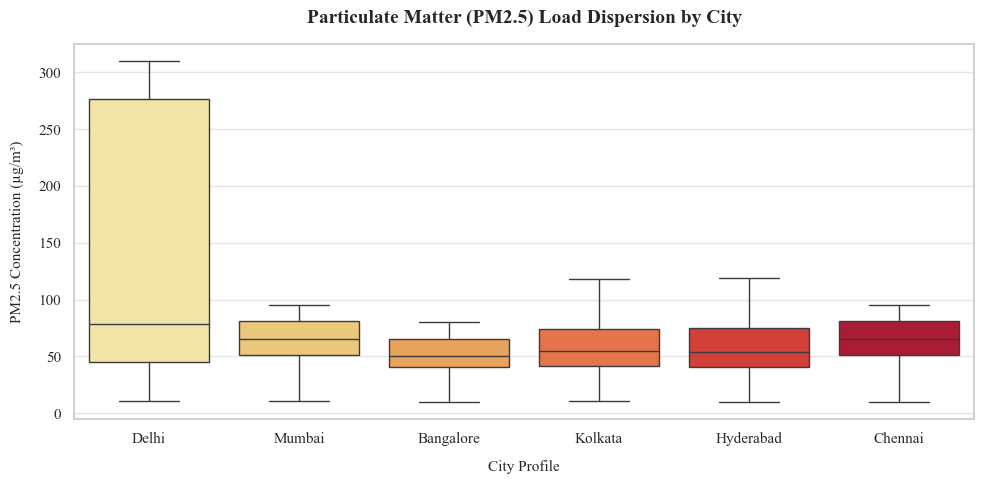

In [6]:
# Charting a fast distribution plot directly inside your active workspace cells
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x='City', y='PM2.5', hue='City', legend=False, palette='YlOrRd', ax=ax)
ax.set_title('Particulate Matter (PM2.5) Load Dispersion by City', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('City Profile', fontsize=11, labelpad=10)
ax.set_ylabel('PM2.5 Concentration (µg/m³)', fontsize=11, labelpad=10)
plt.tight_layout()
plt.show()

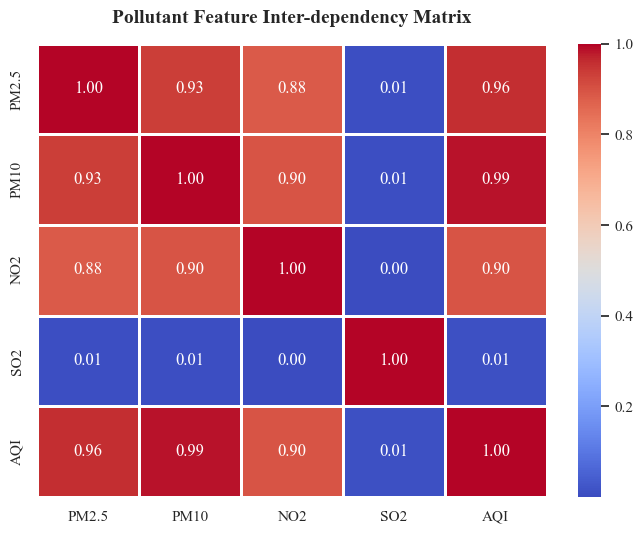

In [7]:
fig, ax = plt.subplots(figsize=(7, 5.5))
corr_matrix = df[['PM2.5', 'PM10', 'NO2', 'SO2', 'AQI']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=1, ax=ax)
ax.set_title('Pollutant Feature Inter-dependency Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()